<a href="https://colab.research.google.com/github/yerardinespinosab15-afk/challengeteleconx1/blob/main/TelecomX_LATAM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#📌 Extracción

In [12]:
import pandas as pd
import requests

# 1. Definimos la ruta o URL del archivo
url = 'https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/5adf5f2f87a72bd8b2e854db16e2f2f7c499081a/TelecomX_Data.json'

# 2. Obtenemos los datos de la ruta
response = requests.get(url)
json_data = response.json()

# 3. Transformamos a DataFrame (Aplanando los datos anidados)
# Usamos record_path si el JSON tiene una raíz específica, pero para este reto
# json_normalize directo suele funcionar para columnas como 'Charges.Total'
df = pd.json_normalize(json_data)

# 4. Verificación inicial
print("Columnas detectadas:", df.columns)
df.head()

Columnas detectadas: Index(['customerID', 'Churn', 'customer.gender', 'customer.SeniorCitizen',
       'customer.Partner', 'customer.Dependents', 'customer.tenure',
       'phone.PhoneService', 'phone.MultipleLines', 'internet.InternetService',
       'internet.OnlineSecurity', 'internet.OnlineBackup',
       'internet.DeviceProtection', 'internet.TechSupport',
       'internet.StreamingTV', 'internet.StreamingMovies', 'account.Contract',
       'account.PaperlessBilling', 'account.PaymentMethod',
       'account.Charges.Monthly', 'account.Charges.Total'],
      dtype='object')


,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


#🔧 Transformación

In [14]:
# Expandir las columnas anidadas si es necesario (normalización)
# Supongamos que queremos limpiar la columna 'TotalCharges' que suele venir como texto
df['account.Charges.Total'] = pd.to_numeric(df['account.Charges.Total'], errors='coerce')

# Eliminar filas con valores nulos tras la conversión
df_limpios = df.dropna()

# Verificar si hay duplicados
df_limpios = df_limpios.drop_duplicates()

df_limpios.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7256 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7256 non-null   object 
 1   Churn                      7256 non-null   object 
 2   customer.gender            7256 non-null   object 
 3   customer.SeniorCitizen     7256 non-null   int64  
 4   customer.Partner           7256 non-null   object 
 5   customer.Dependents        7256 non-null   object 
 6   customer.tenure            7256 non-null   int64  
 7   phone.PhoneService         7256 non-null   object 
 8   phone.MultipleLines        7256 non-null   object 
 9   internet.InternetService   7256 non-null   object 
 10  internet.OnlineSecurity    7256 non-null   object 
 11  internet.OnlineBackup      7256 non-null   object 
 12  internet.DeviceProtection  7256 non-null   object 
 13  internet.TechSupport       7256 non-null   object 
 1

#📊 Carga y análisis

/tmp/ipykernel_190/3546823448.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Churn', data=df_limpios, palette='viridis')


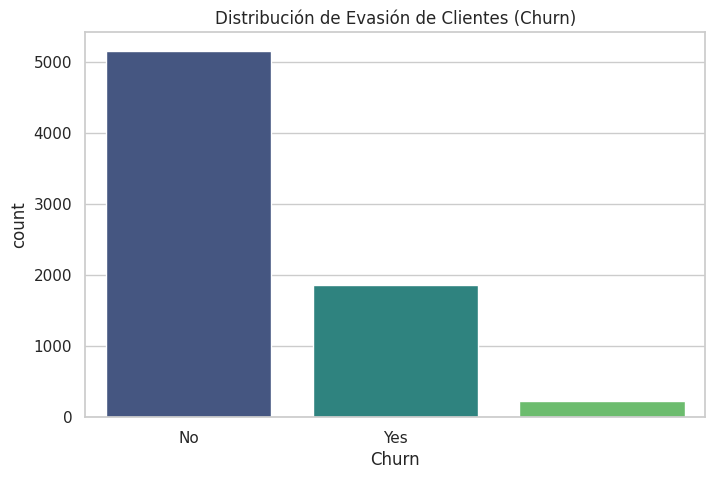

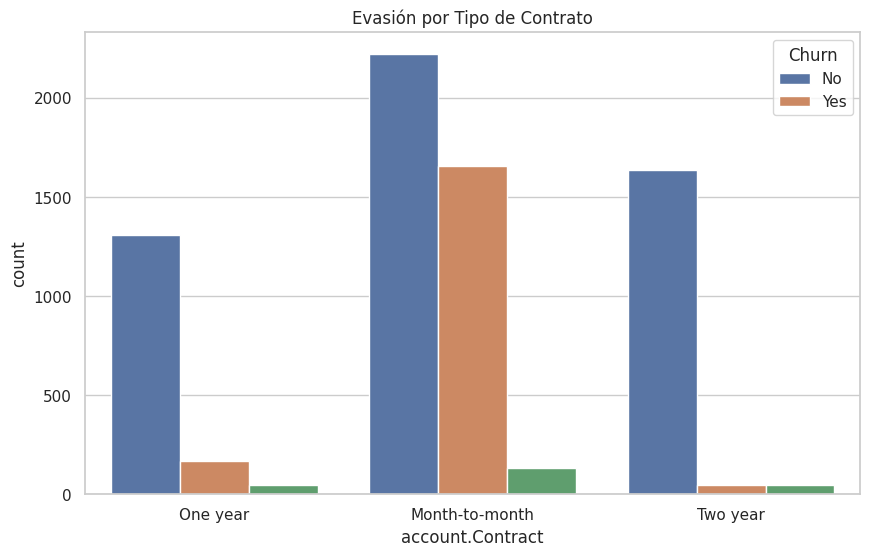

In [16]:
# Configuración visual
sns.set_theme(style="whitegrid")

# Visualizar la distribución de la evasión (Churn)
plt.figure(figsize=(8, 5))
sns.countplot(x='Churn', data=df_limpios, palette='viridis')
plt.title('Distribución de Evasión de Clientes (Churn)')
plt.show()

# ¿El tipo de contrato influye?
plt.figure(figsize=(10, 6))
sns.countplot(x='account.Contract', hue='Churn', data=df_limpios)
plt.title('Evasión por Tipo de Contrato')
plt.show()

#📄Informe final

In [18]:
# Código para obtener datos reales para tu informe
total_clientes = len(df_limpios)
tasa_churn = (df_limpios['Churn'].value_counts(normalize=True)['Yes'] * 100)

print(f"Total de clientes analizados: {total_clientes}")
print(f"Tasa de evasión general: {tasa_churn:.2f}%")

Total de clientes analizados: 7256
Tasa de evasión general: 25.76%


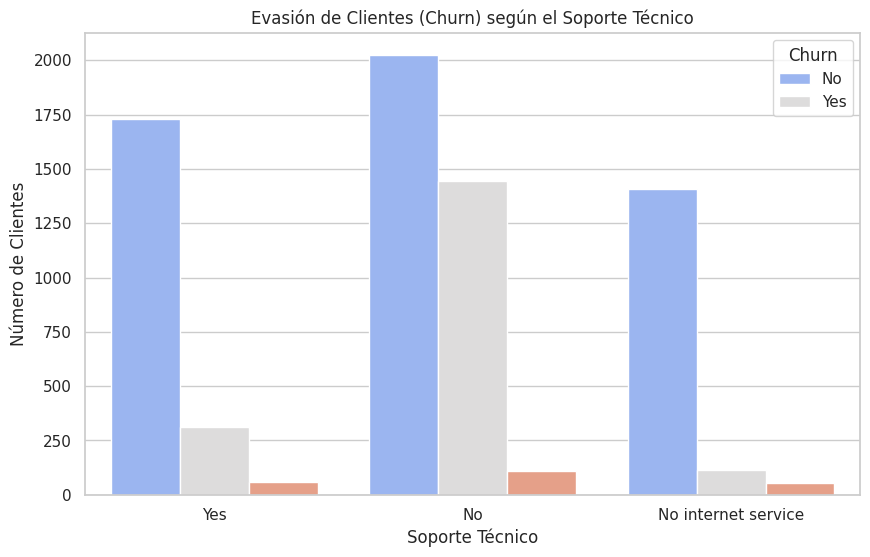

In [19]:
plt.figure(figsize=(10, 6))
sns.countplot(x='internet.TechSupport', hue='Churn', data=df_limpios, palette='coolwarm')
plt.title('Evasión de Clientes (Churn) según el Soporte Técnico')
plt.xlabel('Soporte Técnico')
plt.ylabel('Número de Clientes')
plt.show()